# Parameter estimation with `parmest`

Created by [Kanishka Ghosh](https://github.com/kanishka-ghosh), [Jialu Wang](https://github.com/jialuw96), [Prof. Alex Dowling](https://github.com/adowling2/), and [Stephen Cini](https://github.com/sscini) at the University of Notre Dame. Last updated December 2024.

In [1]:
# This code cell installs packages on Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.install_idaes()
    helper.install_ipopt()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyomo.environ as pyo
import pyomo.dae as dae
import pyomo
import idaes

# Define the directory to save/read the data files
data_dir = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/"

## What is parameter estimation?

Given a function $f(x,\theta)$ where $x$ is the input or array of inputs, $\theta$ is the vector of unknown model parameters, and $y$ is the array of observed output, parameter estimation is performed to determine the values of $\theta$ to minimize the error between $f(x,\theta)$ and $y$.  Commonly, parameter estimation is set up as a least squares objective problem:

$$
\begin{align}
\begin{split}
    \min_{\hat{\theta}} \quad & \sum_{i}^{} (y_i - f(x_i,\hat{\theta}))^2\\
    \textrm{s.t.} \quad & \mathrm{bounds \ on} \ \theta\\
    & \mathrm{other \ physical \ constraints}\\
\end{split}
\end{align}
$$

where $i$ is used to index the datapoints in a dataset and $\hat{\theta}$ is the optimal set of parameter values that minimizes the prediction error.

## What is `parmest`?

`parmest` is a Python package built on the [Pyomo optimization modeling language](http://www.pyomo.org/) to support parameter estimation using experimental data along with confidence regions and subsequent creation of scenarios for [PySP](https://github.com/Pyomo/pysp). `parmest` supports scenario generation for multiple 'experiments' and can be used to characterize estimate uncertainties through, for example, confidence region generations. `parmest` requires the following positional arguments in order solve the optimization problem:

1. `Experiment` class with the following functions:

    __init__ - Loads data into class, and initializes model to contain no information.

    create_model - Define the model in a generic form with needed variables and parameters.
    
    finalize_model - Initialize and/or discretize the model from create_model for use with specified data.
    
    label_model - Add required labels. `parmest` requires the model contains labeled unknown_parameters and model_outputs.
    `pyomo.DoE` additionally requires model_inputs and measurement_error.

    get_labeled_model - Calls previous functions to generate complete model for each `Experiment`.


2. Optional keyword argument to define the verbosity of solver output.  Default: False

More information about the `parmest` package can be found [here](https://pyomo.readthedocs.io/en/6.8.0/contributed_packages/parmest/index.html).

Detailed explanation of the various methods in `parmest` can be found [here](https://www.osti.gov/servlets/purl/1761797).


## Example: Reaction Kinetics

Consider two chemical reactions that convert molecule $A$ to desired product $B$ and a less valuable side-product $C$.

$$A \overset{k_1}{\rightarrow} B \overset{k_2}{\rightarrow} C$$

Our ultimate goal is to design a large-scale continuous reactor that maximizes the production of $B$. This general sequential reactions problem is widely applicable to CO$_2$ capture and industry more broadly (petrochemicals, pharmaceuticals, etc.).

The rate laws for these two chemical reactions are:

$$r_A = -k_1 C_A$$

$$r_B = k_1 C_A - k_2 C_B$$

$$r_C = k_2 C_B$$

Here, $C_A$, $C_B$, and $C_C$ are the concentrations of each species. The rate constants $k_1$ and $k_2$ depend on temperature as follows:

$$k_1 = A_1 \exp{\frac{-E_1}{R T}}$$

$$k_2 = A_2 \exp{\frac{-E_2}{R T}}$$

$A_1, A_2, E_1$, and $E_2$ are fitted model parameters. $R$ is the ideal-gas constant and $T$ is absolute temperature.

### Batch Reactor

The concentrations in a batch reactor evolve with time per the following differential equations:

$$ \frac{d C_A}{dt} = r_A = -k_1 C_A $$

$$ \frac{d C_B}{dt} = r_B = k_1 C_A - k_2 C_B $$

$$ \frac{d C_C}{dt} = r_C = k_2 C_B $$

This is a linear system of differential equations. Assuming the feed is only species $A$, i.e.,

$$C_A(t=0) = C_{A0} \quad C_B(t=0) = 0 \quad C_C(t=0) = 0$$

leads to the following analytic solution:

$$C_A(t) = C_{A,0} \exp(-k_1 t)$$

$$C_B(t) = \frac{k_1}{k_2 - k_1} C_{A,0} \left[\exp(-k_1 t) - \exp(-k_2 t) \right]$$

$$C_C(t) = C_{A,0} - \frac{k_2}{k_2 - k_1} C_{A,0} \exp(-k_1 t) + \frac{k_1}{k_2 - k_1} \exp(-k_2 t) C_{A,0} = C_{A,0} - C_{A}(t) - C_{B}(t)$$

The following Python code simulates and plots this model.

In [3]:
def kinetics(A, E, T):
    """Computes kinetics from Arrhenius equation

    Arguments:
        A: pre-exponential factor, [1 / hr]
        E: activation energy, [kJ / mol]
        T: temperature, [K]

    Returns:
        k: reaction rate coefficient, [1 / hr]

    """
    R = 8.31446261815324  # J / K / mole

    return A * np.exp(-E * 1000 / (R * T))


def concentrations(t, k, CA0):
    """
    Returns concentrations at time t

    Arguments:
        t: time, [hr]
        k: reaction rate coefficient, [1 / hr]
        CA0: initial concentration of A, [mol / L]

    Returns:
        CA, CB, CC: concentrations of A, B, and C at time t, [mol / L]
    """
    CA = CA0 * np.exp(-k[0] * t)
    CB = k[0] * CA0 / (k[1] - k[0]) * (np.exp(-k[0] * t) - np.exp(-k[1] * t))
    CC = CA0 - CA - CB

    return CA, CB, CC

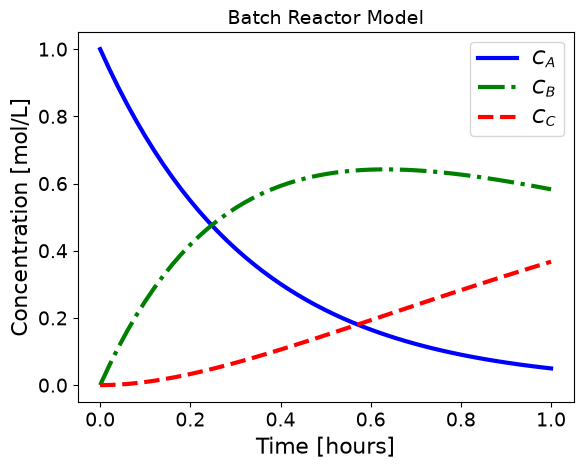

In [4]:
CA0 = 1  # Moles/L
k = [3, 0.7]  # 1/hr

t = np.linspace(0, 1, 51)
CA, CB, CC = concentrations(t, k, CA0)
plt.plot(t, CA, label="$C_{A}$", linestyle="-", color="blue")
plt.plot(t, CB, label="$C_{B}$", linestyle="-.", color="green")
plt.plot(t, CC, label="$C_{C}$", linestyle="--", color="red")
plt.xlabel("Time [hours]")
plt.ylabel("Concentration [mol/L]")
plt.title("Batch Reactor Model")
plt.legend()
plt.show()
plt.close()

### Experimental Data

See the notebook *Supplementary material: data for parmest tutorial* for details on how these experimental data were generated (via simulation).

Experimental data consists of the concentration of species A, B, and C in $\mathrm{mol/L}$ with respect to time $t$ in $\mathrm{hours}$ inside the batch reactor. The experimental data is stored in csv files where the first column records the time $t$ in the reactor. Next, the temperature $T$ in $\mathrm{K}$ at which the reaction was simulated is recorded followed by the initial concentration of species A, $C_{A,0}$, in $\mathrm{mol/L}$. Finally, the time-varying species concentrations ($C_A$), ($C_B$), and ($C_C$) are recorded in $\mathrm{mol/L}$. Following is how the pandas dataframe of a single experiment looks like:

In [5]:
# define function to plot
def plot_exp(k, CA0, data, text):
    """
    Plot concentration profiles
    Arguments:
        k: kinetic parameters
        CA0: initial concentration
        data: Pandas data frame
        text: plot title

    """
    # evaluate models
    t = np.linspace(0, 1, 51)
    CA, CB, CC = concentrations(t, k, CA0)

    # plot model-generated and 'experimental' data
    # symbols for 'experimental' data
    # solid and dashed lines for model-generated data
    plt.plot(t, CA, label="$C_{A}$", linestyle="-", color="blue")
    plt.plot(data.time, data.CA, marker="o", linestyle="", color="blue", label=str())
    plt.plot(t, CB, label="$C_{B}$", linestyle="-.", color="green")
    plt.plot(data.time, data.CB, marker="s", linestyle="", color="green", label=str())
    plt.plot(t, CC, label="$C_{C}$", linestyle="--", color="red")
    plt.plot(data.time, data.CC, marker="^", linestyle="", color="red", label=str())
    plt.xlabel("Time [hours]")
    plt.ylabel("Concentration [mol/L]")
    plt.title(text)
    plt.legend()
    plt.show()
    plt.close()

### Pyomo model

In the following cell, we define a function to define and return the Pyomo model for the kinetic model to be used for parameter estimation.

In [6]:
import pyomo.contrib.parmest.parmest as parmest
from pyomo.contrib.parmest.experiment import Experiment


def reaction_kinetics_model(data):

    # define Pyomo model
    m = pyo.ConcreteModel()
    m.T = data["T"][0]  # K
    m.CA0 = data["CA0"][0]  # mol/L
    m.R = 8.31446261815324  # J / K / mol

    # # define 'experimental' data timesteps as Pyomo set
    m.t = pyo.Set(initialize=data["time"].tolist())

    # Kinetic parameters to be fitted defined as Pyomo variables
    # Initialized by 'true' values
    m.A1 = pyo.Var(initialize=200, bounds=(100, 300))  # 1/hr
    m.A2 = pyo.Var(initialize=400, bounds=(300, 500))  # 1/hr
    m.E1 = pyo.Var(initialize=10, bounds=(1, 20))  # kJ/mol
    m.E2 = pyo.Var(initialize=15, bounds=(1, 30))  # kJ/mol

    # Concentration variables indexed by time
    m.CA = pyo.Var(m.t, initialize=m.CA0)  # mol/L
    m.CB = pyo.Var(m.t, initialize=0)  # mol/L
    m.CC = pyo.Var(m.t, initialize=0)  # mol/L

    # kinetic rate constants from Arrhenius equation
    m.k1 = pyo.Expression(rule=m.A1 * pyo.exp(-m.E1 * 1000 / (m.R * m.T)))  # 1/hr
    m.k2 = pyo.Expression(rule=m.A2 * pyo.exp(-m.E2 * 1000 / (m.R * m.T)))  # 1/hr

    # Constraints to change concentrations based on kinetics
    def conc_A(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        else:
            return m.CA[i] == m.CA0 * pyo.exp(-m.k1 * i)

    m.CA_rate = pyo.Constraint(m.t, rule=conc_A)

    def conc_B(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        else:
            return m.CB[i] == m.k1 * m.CA0 / (m.k2 - m.k1) * (
                pyo.exp(-m.k1 * i) - pyo.exp(-m.k2 * i)
            )

    m.CB_rate = pyo.Constraint(m.t, rule=conc_B)

    def conc_C(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        else:
            return m.CC[i] == m.CA0 - m.CA[i] - m.CB[i]

    m.CC_rate = pyo.Constraint(m.t, rule=conc_C)

    return m


In [6]:
class ReactionKineticsExperiment(Experiment):

    def __init__(self, data):
        self.data = data
        self.model = None

    def create_model(self):
        self.model = m = reaction_kinetics_model(self.data)
        return m

    def finalize_model(self):
        m = self.model

        # Initial Conditions

        m.CA[0].fix(m.CA0)
        m.CB[0].fix(0.0)
        m.CC[0].fix(0.0)

        return m

    def label_model(self):
        m = self.model

        m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_outputs.update(
            (m.CA[t], self.data["CA"][ind]) for ind, t in enumerate(self.data["time"])
        )
        m.experiment_outputs.update(
            (m.CB[t], self.data["CB"][ind]) for ind, t in enumerate(self.data["time"])
        )
        m.experiment_outputs.update(
            (m.CC[t], self.data["CC"][ind]) for ind, t in enumerate(self.data["time"])
        )

        m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.unknown_parameters.update(
            (k, pyo.ComponentUID(k)) for k in [m.A1, m.A2, m.E1, m.E2]
        )

        # Standard deviation of the measurement noise. Pyomo 6.10 requires this
        # suffix to compute the covariance matrix (see `cov_est` below). The value
        # is `stdev_m_error` from the Parmest-generate-data notebook, which is the
        # noise that was added when these data files were generated.
        m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.measurement_error.update((k, 0.1) for k in m.experiment_outputs)
        return m

    def get_labeled_model(self):
        m = self.create_model()
        m = self.finalize_model()
        m = self.label_model()
        # m.pprint()

        return m

    time    T  CA0        CA        CB        CC
0  0.000  250  0.5  0.676405  0.041060  0.031307
1  0.125  250  0.5  0.447945  0.104749  0.000000
2  0.250  250  0.5  0.430686  0.306222  0.000000
3  0.375  250  0.5  0.495617  0.291236  0.078701
4  0.500  250  0.5  0.408284  0.268605  0.108478
5  0.625  250  0.5  0.083008  0.331605  0.000000
6  0.750  250  0.5  0.242464  0.342886  0.270002
7  0.875  250  0.5  0.105167  0.474409  0.000000
8  1.000  250  0.5  0.087828  0.314504  0.071406


Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

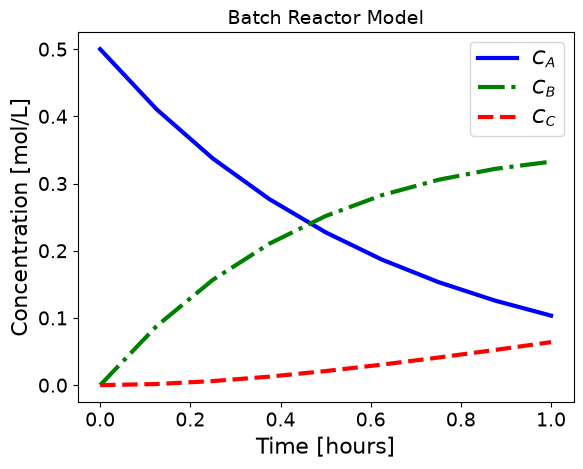

In [7]:
# Test model
data = pd.read_csv(data_dir + "parmest_20210609_data_exp1.csv", index_col=0)
print(data)

m = reaction_kinetics_model(data)

m.CA[0].fix(m.CA0)
m.CB[0].fix(0.0)
m.CC[0].fix(0.0)

# solve model

solver = pyo.SolverFactory("ipopt")

# solve model
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)
# m.pprint()

# plot results
CA = [pyo.value(m.CA[i]) for i in m.t]
CB = [pyo.value(m.CB[i]) for i in m.t]
CC = [pyo.value(m.CC[i]) for i in m.t]
plt.plot(m.t, CA, label="$C_{A}$", linestyle="-", color="blue")
plt.plot(m.t, CB, label="$C_{B}$", linestyle="-.", color="green")
plt.plot(m.t, CC, label="$C_{C}$", linestyle="--", color="red")
plt.xlabel("Time [hours]")
plt.ylabel("Concentration [mol/L]")
plt.title("Batch Reactor Model")
plt.legend()

## Parameter estimation with a single dataset

Here, we will estimate parameters $A_1$, $A_2$, $E_1$, and $E_2$ using data generated for a batch 'experiment' at 250 K with an inlet concentration of 0.5 mol/L of A.

The parameter estimation problem is solved with the least squares optimization scheme
$$
\begin{align}
\begin{split}
    \min_{\hat{\theta}} \quad & \sum_{i}^{} (y_i - f(x_i,\hat{\theta}))^2\\
    \textrm{s.t.} \quad & \mathrm{bounds \ on} \ \theta\\
    & \mathrm{other \ physical \ constraints}\\
\end{split}
\end{align}
$$
where $i$ is used to index the datapoints in a dataset and $\hat{\theta}$ is the optimal set of parameter values that minimizes the prediction error.


In [8]:
# # read-in data from csv file
data = pd.read_csv(data_dir + "parmest_20210609_data_exp1.csv", index_col=0)

# # run parmest

exp_list = []
df = data

exp_list.append(ReactionKineticsExperiment(df))

pest = parmest.Estimator(exp_list, obj_function="SSE", tee=True)

obj, theta = pest.theta_est()


print("===  Parameter values  ===")
print("A1 = {:0.3f} 1/hr".format(theta["A1"]))
print("A2 = {:0.3f} 1/hr".format(theta["A2"]))
print("E1 = {:0.3f} kJ/mol".format(theta["E1"]))
print("E2 = {:0.3f} kJ/mol".format(theta["E2"]))

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

===  Parameter values  ===
A1 = 199.995 1/hr
A2 = 399.938 1/hr
E1 = 10.093 kJ/mol
E2 = 15.507 kJ/mol


## Parameter estimation with multiple datasets

Here, we will estimate parameters $A_1$, $A_2$, $E_1$, and $E_2$ using data generated for a batch 'experiment' at 250 K with an inlet concentration of 0.5 mol/L of A.

The parameter estimation problem is now defined to solve optimization problem where the objective function is the mean of the least square error between observed and calculated data for multiple experiments.

$$
\begin{align}
\begin{split}
    \min_{\hat{\theta}} \quad & \frac{1}{N}\sum_{j}^{}\sum_{i}^{} (y_{j,i} - f(x_{j,i},\hat{\theta}))^2\\
    \textrm{s.t.} \quad & \mathrm{bounds \ on} \ \theta\\
    & \mathrm{other \ physical \ constraints}\\
\end{split}
\end{align}
$$

where $i$ is used to index the datapoints in a dataset, $j$ is an index on the dataset such that $j \in [1,N]$ and $N$ is the number of experiments conducted.

### Generate Experiment list

In the following cell, we define a function to generate a list of Experiments using the `Experiment` class.  For this, we read-in the list of file names generated earlier.

In [9]:
# Make empty experiment list
exp_list = []

# Set generic file name to fill with data 1-16
file_name_generic = data_dir + "parmest_20210609_data_exp{}.csv"

for i in range(
    16
):  # making a list of different experiments, each exp has corresponding data
    df = pd.read_csv(file_name_generic.format(i + 1), index_col=0)
    # print(df.head())
    exp_list.append(ReactionKineticsExperiment(df))

### Parameter estimation with parmest

In the following cell, we perform parameter estimation using parmest to solve the least squares problem defined in the Pyomo model.

In Google Colab, an error appears: '_PyDrive2ImportHook' object has no attribute 'find_spec'. This is being fixed by a recent patch to Pyomo: https://github.com/Pyomo/pyomo/pull/3444. Results generated using local run of software.

In [10]:
# run parmest

pest = parmest.Estimator(exp_list, obj_function="SSE")

obj, theta = pest.theta_est()

# print(theta)


print("===  Parameter values  ===")
print("A1 = {:0.3f} 1/hr".format(theta["A1"]))
print("A2 = {:0.3f} 1/hr".format(theta["A2"]))
print("E1 = {:0.3f} kJ/mol".format(theta["E1"]))
print("E2 = {:0.3f} kJ/mol".format(theta["E2"]))

===  Parameter values  ===
A1 = 204.414 1/hr
A2 = 390.586 1/hr
E1 = 10.046 kJ/mol
E2 = 15.021 kJ/mol


### Plotting fitted model simulation with 'experimental' data

Next, we plot the 'experimental' data along with the profiles generated using the fitted kinetic model.  The symbols represent the 'experimental' data and the solid and dashed lines are the profiles generated using the fitted model.

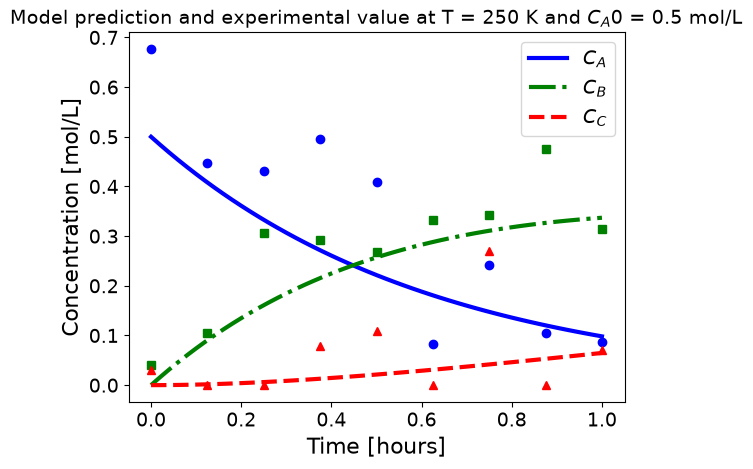

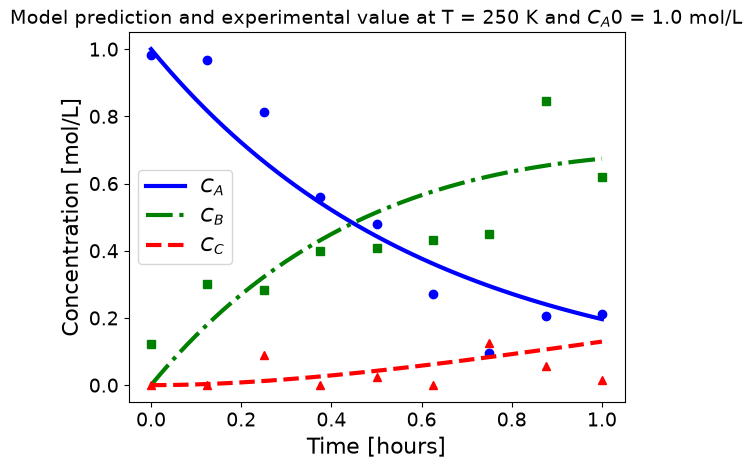

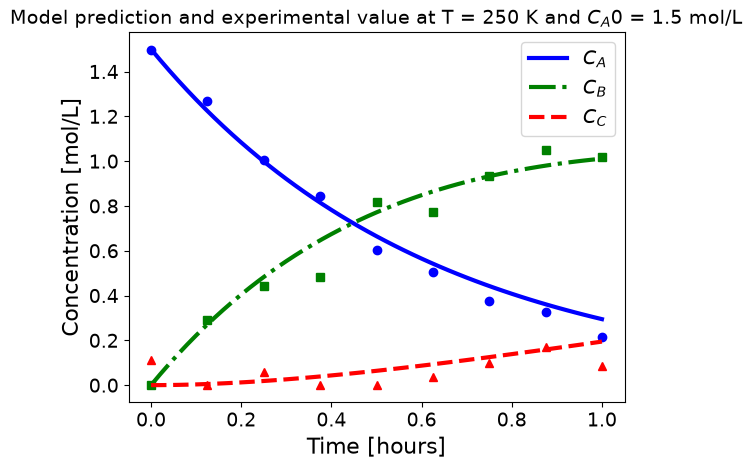

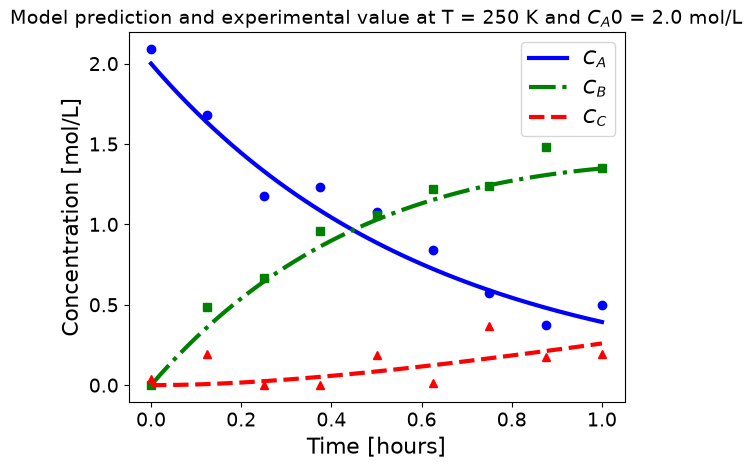

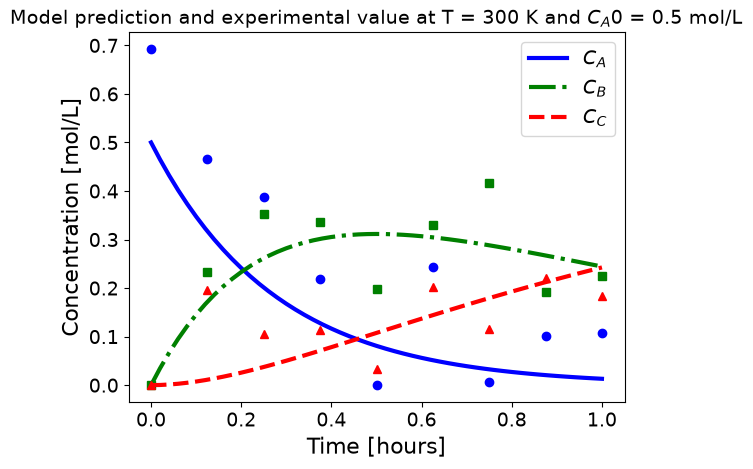

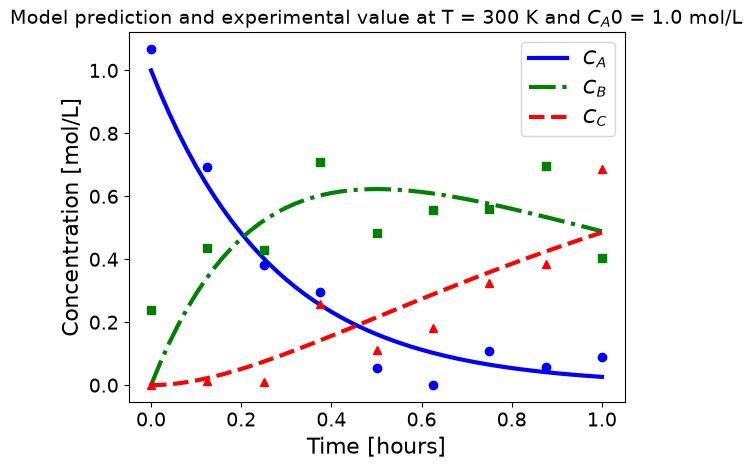

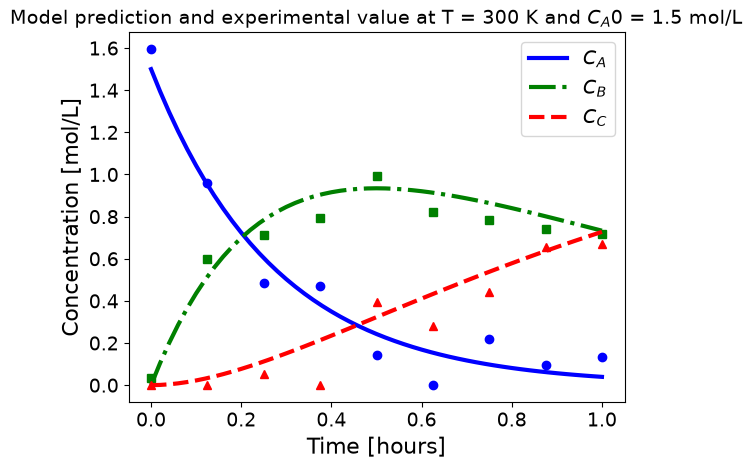

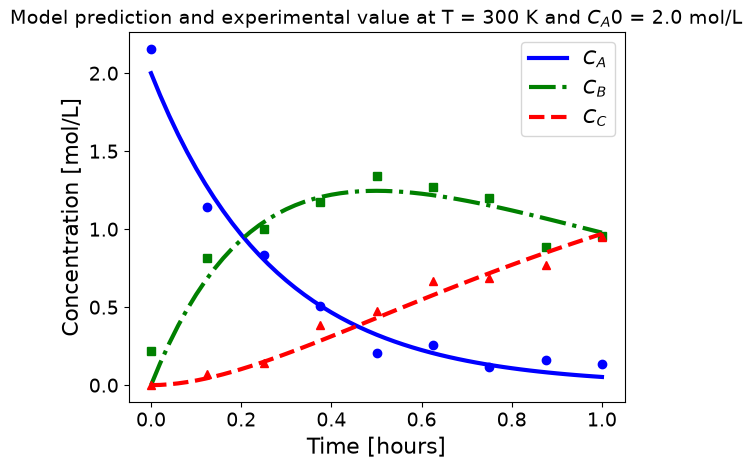

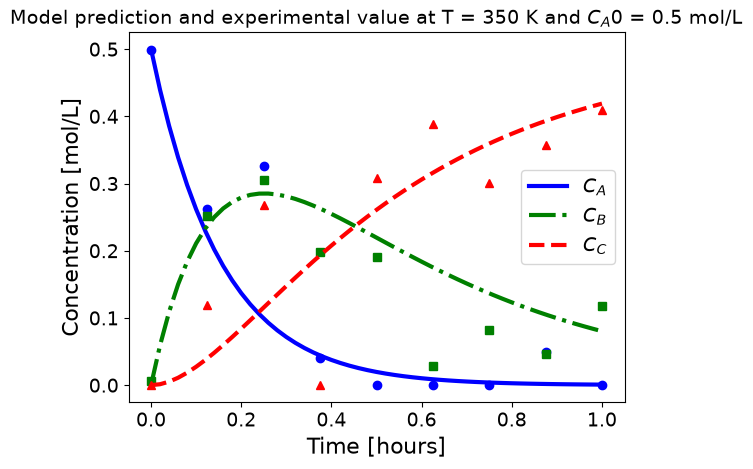

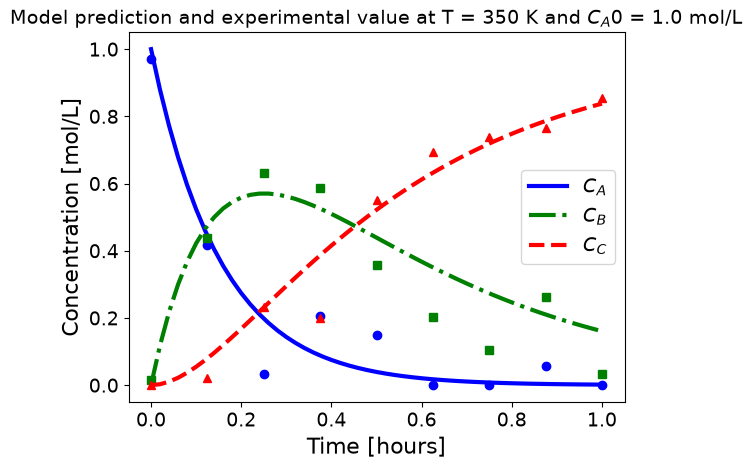

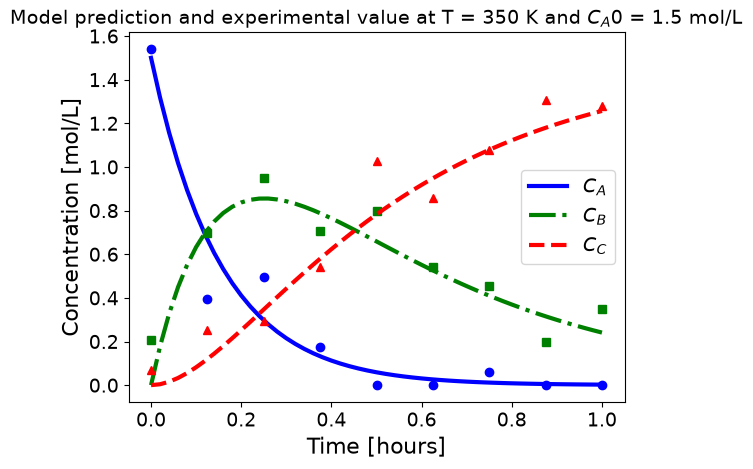

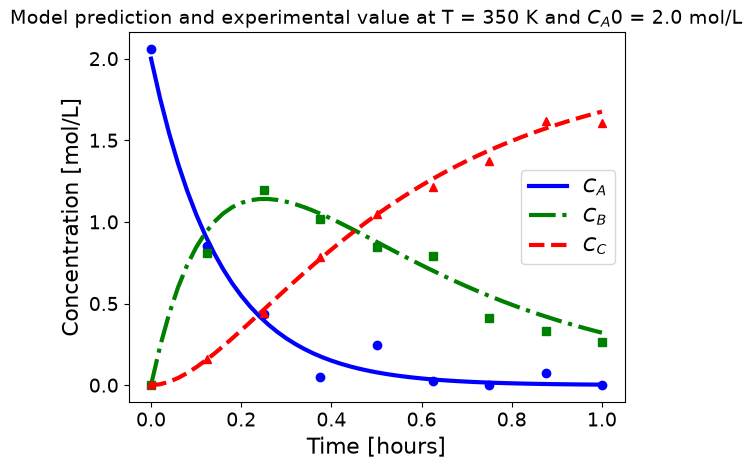

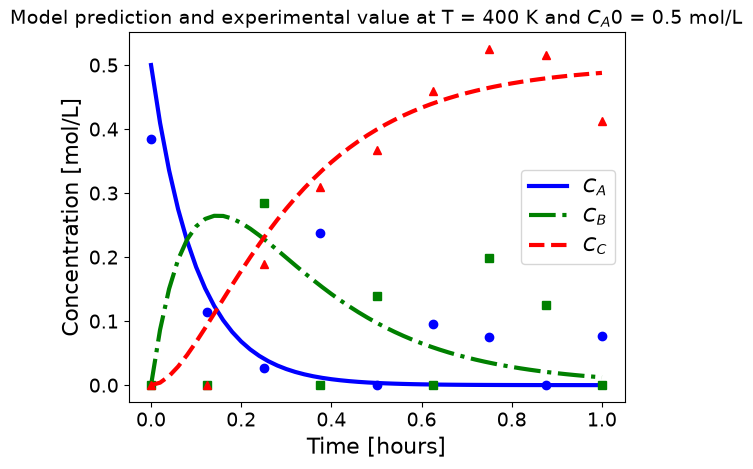

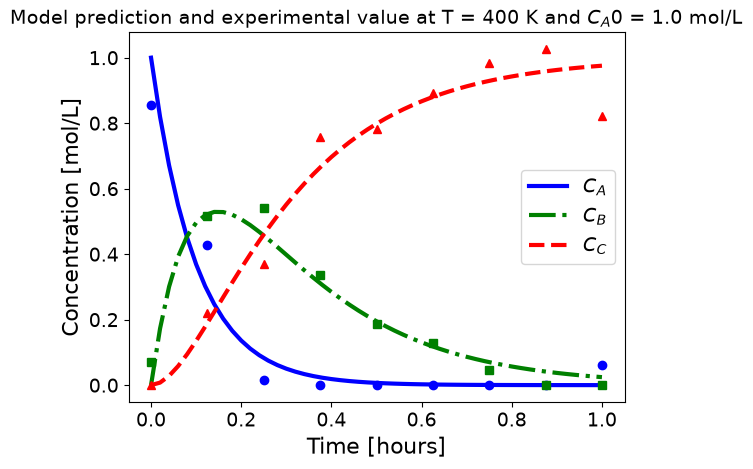

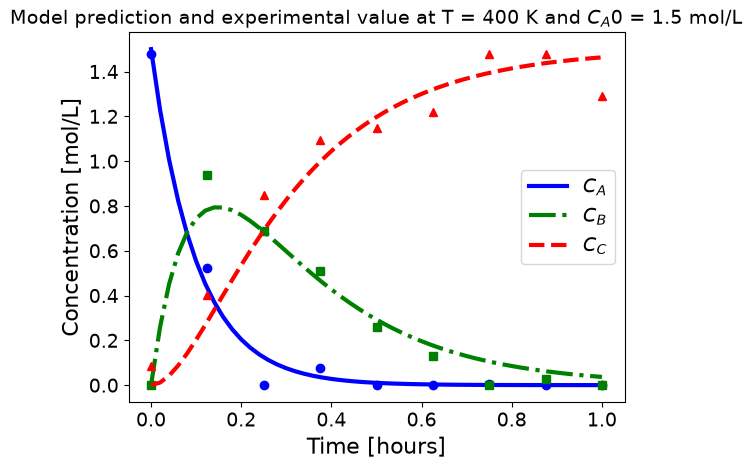

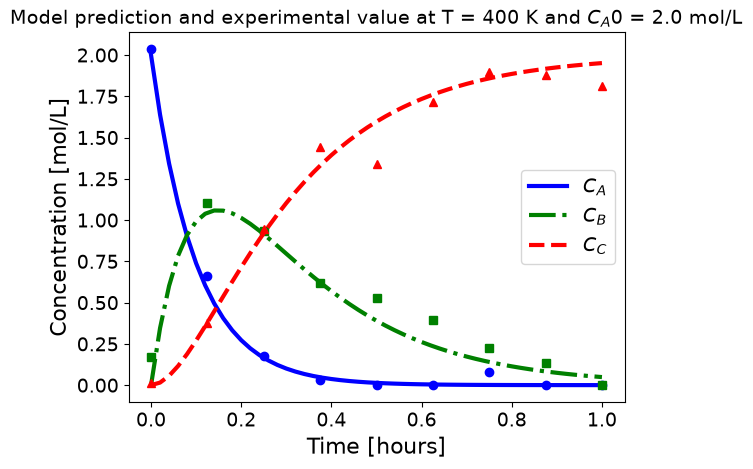

In [11]:
# list of temperatures
T_vals = [250, 300, 350, 400]  # K

# list of initial concentrations of A
CA0_vals = [0.5, 1.0, 1.5, 2.0]  # mol/L

# Parameter values from parameter estimation using parmest
A1 = theta["A1"]
E1 = theta["E1"]
A2 = theta["A2"]
E2 = theta["E2"]


A_est1 = [A1, A2]
A_est = np.asarray(A_est1)

E_est1 = [E1, E2]
E_est = np.asarray(E_est1)

ctr = 0
for T in T_vals:
    for CA0 in CA0_vals:
        # generate concentration profiles using estimated parameter values
        k = kinetics(A_est, E_est, T)
        # plot model-generated and 'experimental' data
        # symbols for 'experimental' data
        # solid and dashed lines for model-generated data
        df = pd.read_csv(file_name_generic.format(ctr + 1), index_col=0)
        plot_exp(
            k,
            CA0,
            df,
            "Model prediction and experimental value at T = {} K and $C_{}$ = {} mol/L".format(
                T, "A0", CA0
            ),
        )
        ctr += 1

## Using `parmest` with `pyomo.dae`

In contrast to the approach above, we will now try to solve the model without the analytic solution for the concentrations using Pyomo.DAE.  To recap, the concentrations in a batch reactor evolve with time per the following differential equations:

$$ \frac{d C_A}{dt} = r_A = -k_1 C_A $$

$$ \frac{d C_B}{dt} = r_B = k_1 C_A - k_2 C_B $$

$$ \frac{d C_C}{dt} = r_C = k_2 C_B $$

This is a linear system of differential equations. Assuming the feed is only species $A$, i.e.,

$$C_A(t=0) = C_{A0} \quad C_B(t=0) = 0 \quad C_C(t=0) = 0$$

In the following cell, we define a function to define and return the Pyomo DAE model (dynamic mode) for the kinetic model to be used for parameter estimation.  In this model, the rate equations are presented in terms of linear differential equations.

````{note}
**A note on units.** This `pyomo.dae` model records its units in comments
(`# 1/hr`, `# mol/L`, `# kJ/mol`) rather than with Pyomo's `units=` argument, unlike
the dynamic optimization notebooks in
[](../3/units_and_pyomo_dae.md). That is a deliberate scope decision, not an
oversight: the model is consumed by `parmest`, which builds the sum-of-squares
objective and clones the model per experiment, and `m.T` is assigned as a plain Python
attribute rather than a Pyomo `Param`. Annotating it properly means annotating the
experiment data columns too.

It is worth seeing what the comments are hiding, though. The Arrhenius expression is

```python
m.k1 = pyo.Expression(rule=m.A1 * pyo.exp(-m.E1 * 1000 / (m.R * m.T)))
```

That bare `1000` is a **hand-rolled unit conversion**: `E1` is in kJ/mol and `R` is in
J/(K·mol), so the activation energy must be multiplied by 1000 to reach joules. Nothing
in the code says so. Get the factor wrong -- or drop it when you refactor -- and the
model still runs, still converges, and returns confidently wrong kinetic parameters.

This is precisely the class of error `assert_units_consistent` exists to catch. If `E1`
carried `units.kJ / units.mol` and `R` carried `units.J / units.K / units.mol`, Pyomo
would do the conversion itself and the `1000` would disappear.

The exponent's argument must also come out **dimensionless**, which is a free check on
the whole expression:

$$
\frac{[\mathrm{kJ}/\mathrm{mol}] \cdot 1000}
     {[\mathrm{J}/(\mathrm{K}\cdot\mathrm{mol})] \cdot [\mathrm{K}]}
= \frac{\mathrm{J}/\mathrm{mol}}{\mathrm{J}/\mathrm{mol}} = 1 .
$$

And note the same `ContinuousSet` limitation as everywhere else: `m.t` is initialized
from `data["time"]` in **hours**, and there is nowhere to record that. See
[Pyomo issue #1790](https://github.com/Pyomo/pyomo/issues/1790).
````


In [12]:
import pyomo.contrib.parmest.parmest as parmest
from pyomo.contrib.parmest.experiment import Experiment


def reaction_kinetics_model_dae(data):

    # define Pyomo model
    m = pyo.ConcreteModel()
    m.T = data["T"][0]  # K
    m.CA0 = data["CA0"][0]  # mol/L
    m.R = 8.31446261815324  # J / K / mol

    # # define 'experimental' data timesteps as Pyomo set
    m.t = dae.ContinuousSet(initialize=data["time"].tolist(), bounds=(0, 1))

    # Kinetic parameters to be fitted defined as Pyomo variables
    # Initialized by 'true' values
    m.A1 = pyo.Var(initialize=200, bounds=(100, 300))  # 1/hr
    m.A2 = pyo.Var(initialize=400, bounds=(300, 500))  # 1/hr
    m.E1 = pyo.Var(initialize=10, bounds=(1, 20))  # kJ/mol
    m.E2 = pyo.Var(initialize=15, bounds=(1, 30))  # kJ/mol

    # Concentration variables indexed by time
    m.CA = pyo.Var(m.t, initialize=m.CA0)  # mol/L
    m.CB = pyo.Var(m.t, initialize=0)  # mol/L
    m.CC = pyo.Var(m.t, initialize=0)  # mol/L

    # Derivatives of concentration
    m.dCA = dae.DerivativeVar(m.CA, wrt=m.t)
    m.dCB = dae.DerivativeVar(m.CB, wrt=m.t)
    m.dCC = dae.DerivativeVar(m.CC, wrt=m.t)

    # kinetic rate constants from Arrhenius equation
    m.k1 = pyo.Expression(rule=m.A1 * pyo.exp(-m.E1 * 1000 / (m.R * m.T)))  # 1/hr
    m.k2 = pyo.Expression(rule=m.A2 * pyo.exp(-m.E2 * 1000 / (m.R * m.T)))  # 1/hr

    # Constraints to change concentrations based on kinetics
    def conc_A(m, i):

        return m.dCA[i] == -m.k1 * m.CA[i]

    m.CA_rate = pyo.Constraint(m.t, rule=conc_A)

    def conc_B(m, i):

        return m.dCB[i] == m.k1 * m.CA[i] - m.k2 * m.CB[i]

    m.CB_rate = pyo.Constraint(m.t, rule=conc_B)

    def conc_C(m, i):

        return m.dCC[i] == m.k2 * m.CB[i]

    m.CC_rate = pyo.Constraint(m.t, rule=conc_C)

    return m


class ReactionKineticsExperiment_dae(Experiment):

    def __init__(self, data):  # , experiment_number):
        self.data = data
        self.model = None

    def create_model(self):
        self.model = m = reaction_kinetics_model_dae(self.data)
        return m

    def finalize_model(self):
        m = self.model

        # Initial Conditions
        m.CA0 = self.data["CA0"][0]
        m.T = self.data["T"][0]

        m.CA[0].fix(m.CA0)
        m.CB[0].fix(0.0)
        m.CC[0].fix(0.0)

        # Initialize the model with simulator
        sim = dae.Simulator(m, package="casadi")
        tsim, profiles = sim.simulate(numpoints=100, integrator="idas")

        sim.initialize_model()

        # Discretize model using collocation
        discretizer = pyo.TransformationFactory("dae.collocation")
        discretizer.apply_to(m, wrt=m.t, nfe=20, ncp=4, scheme="LAGRANGE-RADAU")

        return m

    def label_model(self):
        m = self.model

        m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_outputs.update(
            (m.CA[t], self.data["CA"][ind]) for ind, t in enumerate(self.data["time"])
        )
        m.experiment_outputs.update(
            (m.CB[t], self.data["CB"][ind]) for ind, t in enumerate(self.data["time"])
        )
        m.experiment_outputs.update(
            (m.CC[t], self.data["CC"][ind]) for ind, t in enumerate(self.data["time"])
        )

        m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.unknown_parameters.update(
            (k, pyo.ComponentUID(k)) for k in [m.A1, m.A2, m.E1, m.E2]
        )

        return m

    def get_labeled_model(self):
        m = self.create_model()
        m = self.finalize_model()
        m = self.label_model()

        return m

    time    T  CA0        CA        CB        CC
0  0.000  250  0.5  0.676405  0.041060  0.031307
1  0.125  250  0.5  0.447945  0.104749  0.000000
2  0.250  250  0.5  0.430686  0.306222  0.000000
3  0.375  250  0.5  0.495617  0.291236  0.078701
4  0.500  250  0.5  0.408284  0.268605  0.108478
5  0.625  250  0.5  0.083008  0.331605  0.000000
6  0.750  250  0.5  0.242464  0.342886  0.270002
7  0.875  250  0.5  0.105167  0.474409  0.000000
8  1.000  250  0.5  0.087828  0.314504  0.071406


Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

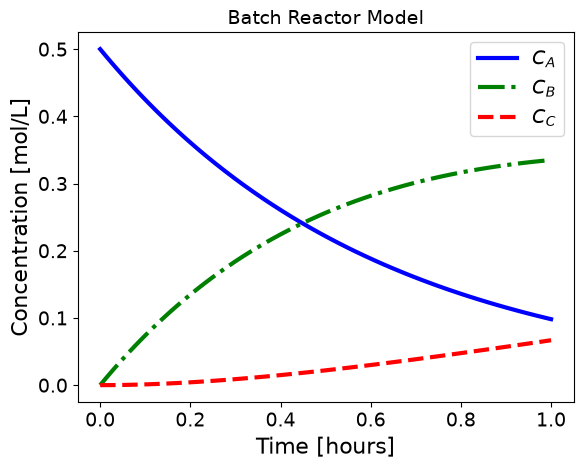

In [13]:
# Test model

data = pd.read_csv(data_dir + "parmest_20210609_data_exp1.csv", index_col=0)
print(data)

m = reaction_kinetics_model_dae(data)

# discretize
discretizer = pyo.TransformationFactory("dae.collocation")
discretizer.apply_to(m, wrt=m.t, nfe=20, ncp=4, scheme="LAGRANGE-RADAU")

# Fix the kinetic parameters at their 'true' values
m.A1.fix(200)  # 1/hr
m.A2.fix(400)  # 1/hr
m.E1.fix(10)  # kJ/mol
m.E2.fix(15)  # kJ/mol

m.CA[0].fix(m.CA0)
m.CB[0].fix(0.0)
m.CC[0].fix(0.0)

# # solve model
solver = pyo.SolverFactory("ipopt")

# solve model
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)
# m.pprint()

# plot results
CA = [pyo.value(m.CA[i]) for i in m.t]
CB = [pyo.value(m.CB[i]) for i in m.t]
CC = [pyo.value(m.CC[i]) for i in m.t]
plt.plot(m.t, CA, label="$C_{A}$", linestyle="-", color="blue")
plt.plot(m.t, CB, label="$C_{B}$", linestyle="-.", color="green")
plt.plot(m.t, CC, label="$C_{C}$", linestyle="--", color="red")
plt.xlabel("Time [hours]")
plt.ylabel("Concentration [mol/L]")
plt.title("Batch Reactor Model")
plt.legend()

### Parameter estimation with parmest

In the following cell, we perform parameter estimation using parmest to solve the least squares problem defined in the Pyomo dynamic model.

In [14]:
# list of temperatures
T_vals = [250, 300, 350, 400]  # K

# list of initial concentrations of A
CA0_vals = [0.5, 1.0, 1.5, 2.0]  # mol/L

# run parmest

exp_list = []

for i in range(
    16
):  # making a list of different experiments, each exp has corresponding data
    df = pd.read_csv(file_name_generic.format(i + 1), index_col=0)
    # print(df.head())
    exp_list.append(ReactionKineticsExperiment_dae(df))

pest = parmest.Estimator(exp_list, obj_function="SSE")  # , tee = True)

obj, theta = pest.theta_est()

# print(theta)


print("===  Parameter values  ===")
print("A1 = {:0.3f} 1/hr".format(theta["A1"]))
print("A2 = {:0.3f} 1/hr".format(theta["A2"]))
print("E1 = {:0.3f} kJ/mol".format(theta["E1"]))
print("E2 = {:0.3f} kJ/mol".format(theta["E2"]))

CasADi - 2026-08-22 11:12:26 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:698]


===  Parameter values  ===
A1 = 204.414 1/hr
A2 = 390.586 1/hr
E1 = 10.046 kJ/mol
E2 = 15.021 kJ/mol


### Plotting fitted model simulation with 'experimental' data

Next, we plot the 'experimental' data along with the profiles generated using the fitted kinetic model.  The symbols represent the 'experimental' data and the solid and dashed lines are the profiles generated using the fitted model.

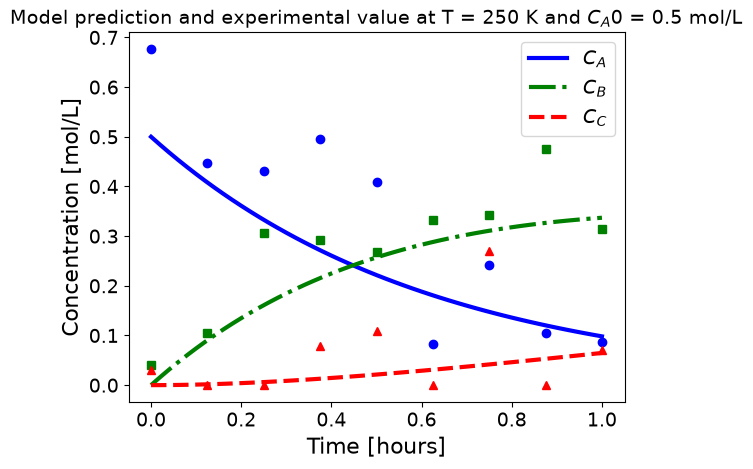

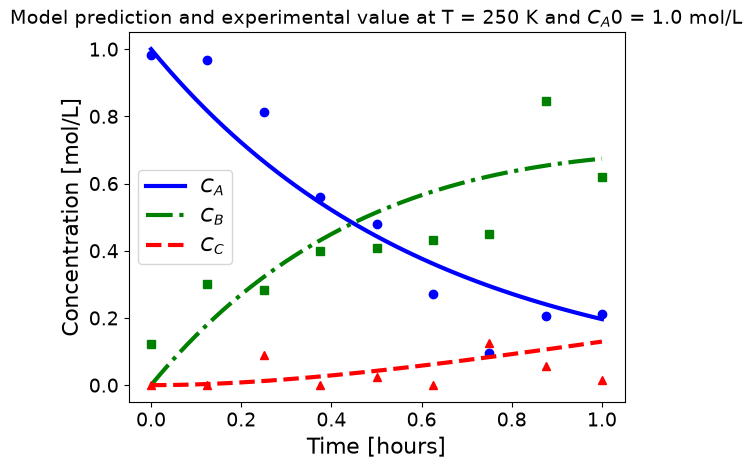

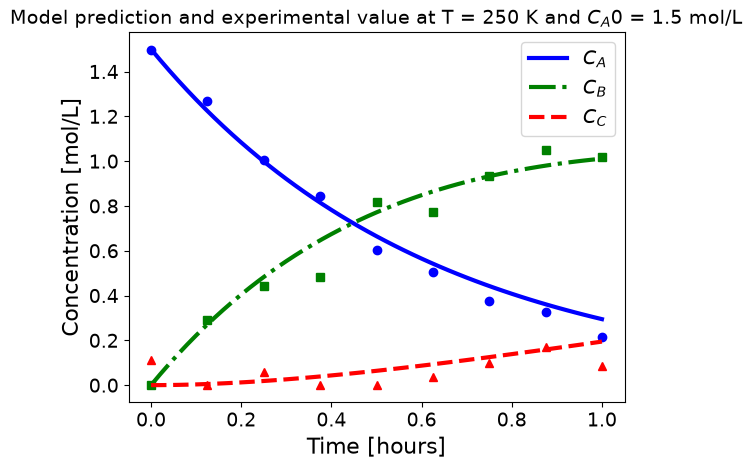

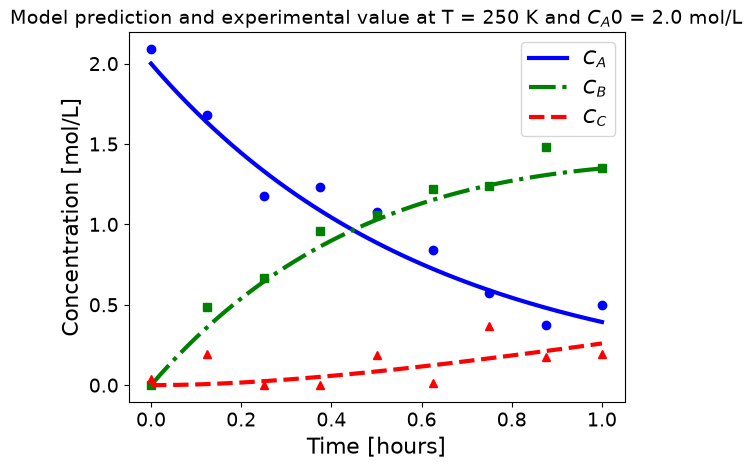

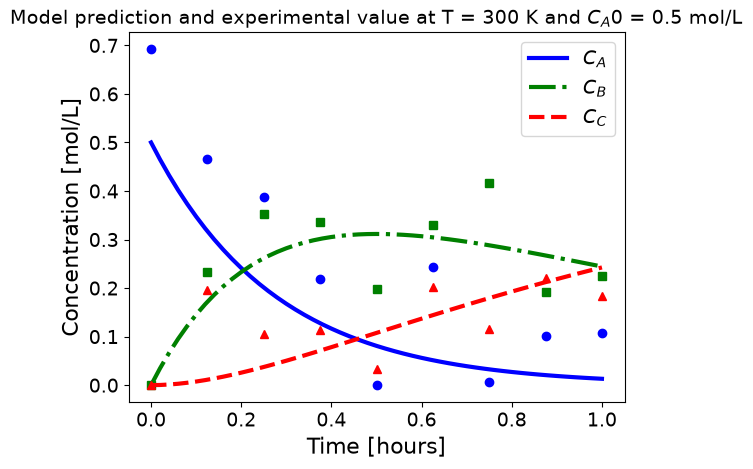

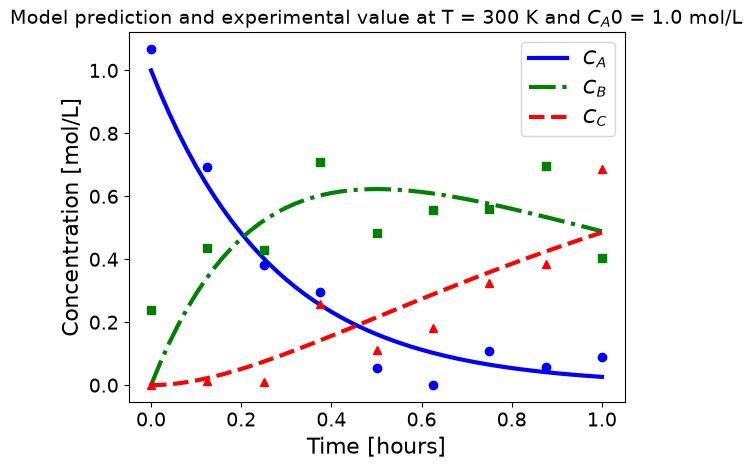

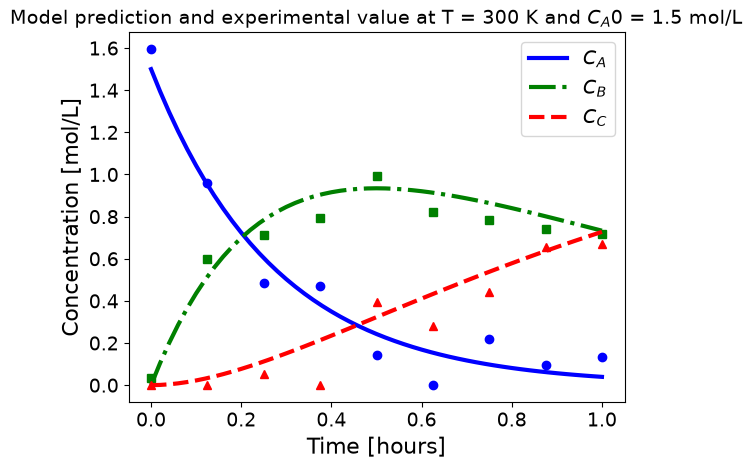

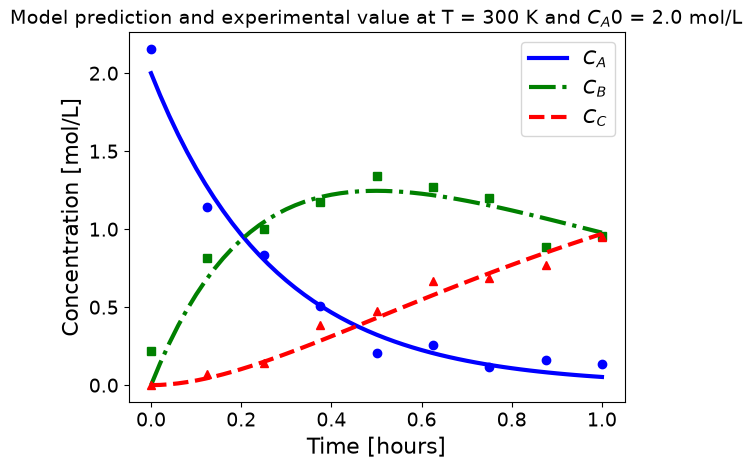

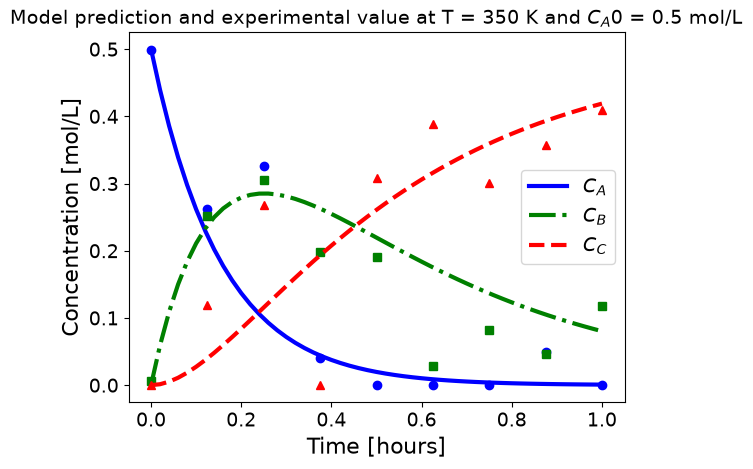

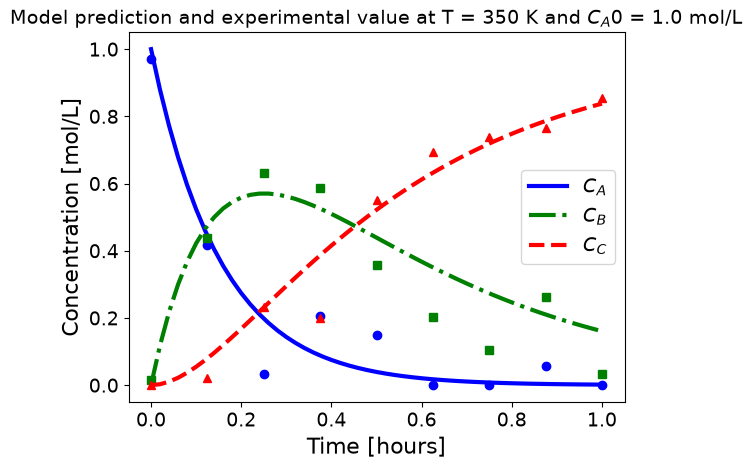

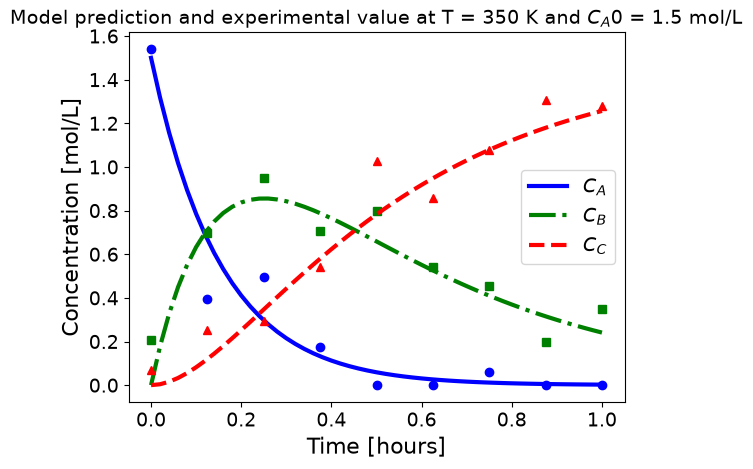

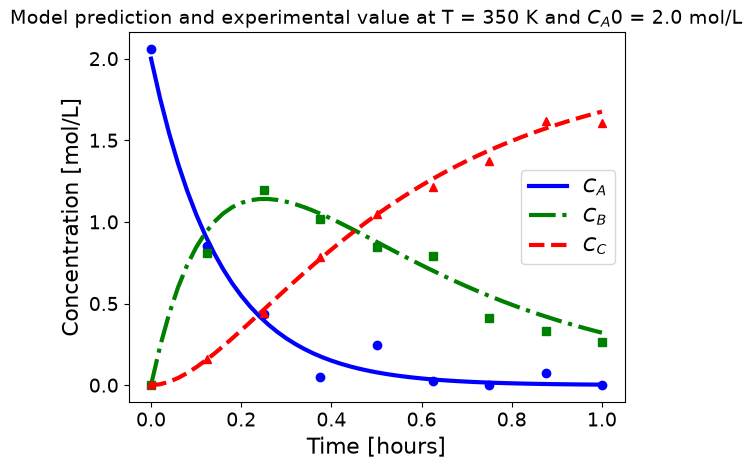

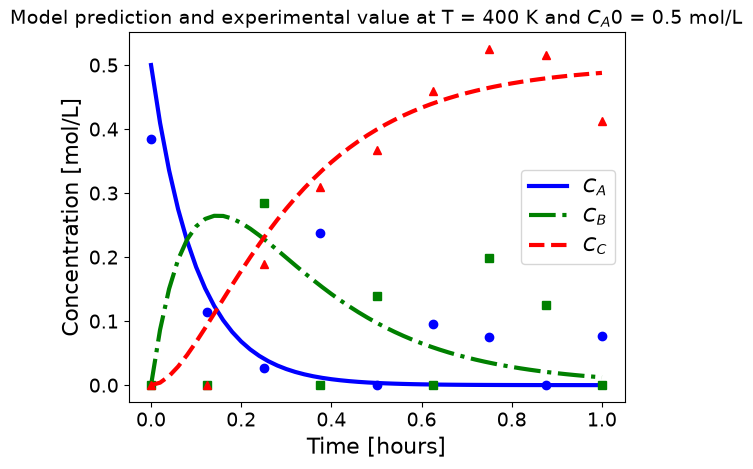

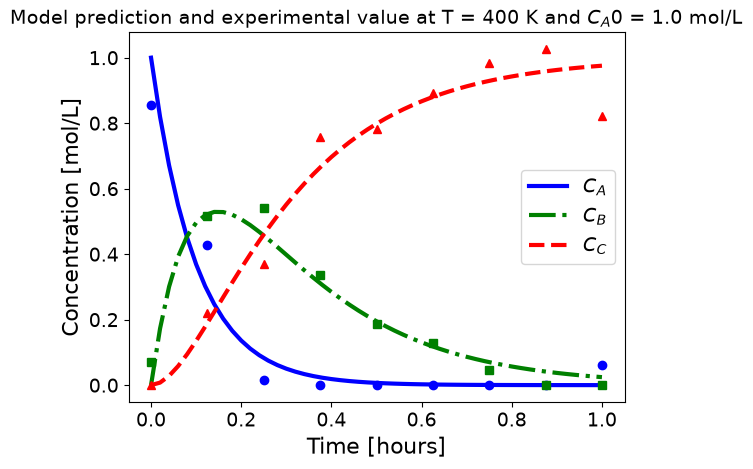

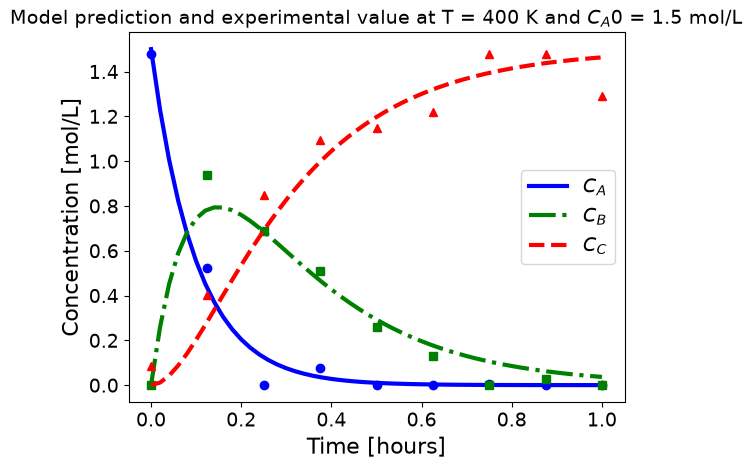

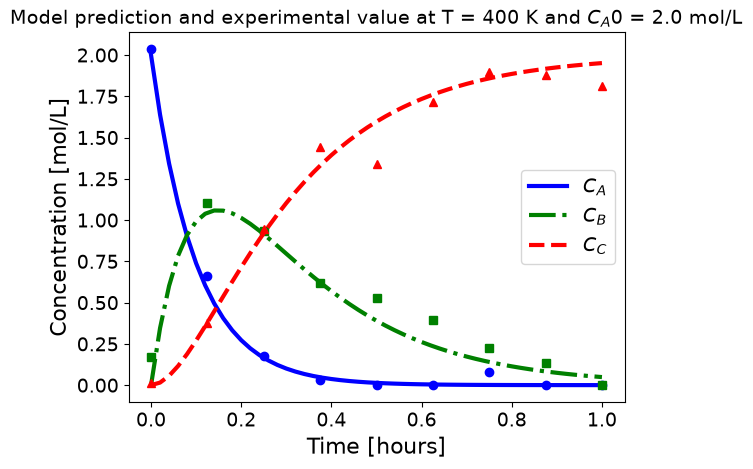

In [15]:
# Parameter values from parameter estimation using parmest
A1 = theta["A1"]
E1 = theta["E1"]
A2 = theta["A2"]
E2 = theta["E2"]


A_est1 = [A1, A2]
A_est = np.asarray(A_est1)

E_est1 = [E1, E2]
E_est = np.asarray(E_est1)

ctr = 0
for T in T_vals:
    for CA0 in CA0_vals:
        # generate concentration profiles using estimated parameter values
        k = kinetics(A_est, E_est, T)
        # plot model-generated and 'experimental' data
        # symbols for 'experimental' data
        # solid and dashed lines for model-generated data
        df = pd.read_csv(file_name_generic.format(ctr + 1), index_col=0)
        plot_exp(
            k,
            CA0,
            df,
            "Model prediction and experimental value at T = {} K and $C_{}$ = {} mol/L".format(
                T, "A0", CA0
            ),
        )
        ctr += 1

## Local uncertainty analysis

### Covariance matrix
The parameter covariance matrix is calculated using the reduced Hessian approach. Using `parmest`, the covariance matrix can be calculated by setting optional argument `calc_cov` to `True`. More information on this approach can be found here: https://doi.org/10.1002/aic.16242

In [16]:
# run parmest

exp_list = []

for i in range(
    16
):  # making a list of different experiments, each exp has corresponding data
    df = pd.read_csv(file_name_generic.format(i + 1), index_col=0)
    # print(df.head())
    exp_list.append(ReactionKineticsExperiment(df))

pest = parmest.Estimator(exp_list, obj_function="SSE")

obj, theta = pest.theta_est()

# Pyomo 6.10: the calc_cov/cov_n arguments to theta_est() are deprecated;
# the covariance matrix is now computed by a separate method.
cov = pest.cov_est(method="reduced_hessian")
# print(cov)

# print(theta)


print("===  Parameter values  ===")
print("A1 = {:0.3f} 1/hr".format(theta["A1"]))
print("A2 = {:0.3f} 1/hr".format(theta["A2"]))
print("E1 = {:0.3f} kJ/mol".format(theta["E1"]))
print("E2 = {:0.3f} kJ/mol".format(theta["E2"]))

===  Parameter values  ===
A1 = 204.414 1/hr
A2 = 390.586 1/hr
E1 = 10.046 kJ/mol
E2 = 15.021 kJ/mol


### Parameter identifiability

The Fisher information matrix, $FIM$, is calculated as the inverse of the parameter covariance matrix:
$FIM = {(Cov.)}^{-1}$

Because the FIM is real and symmetric, its eigendecomposition is $FIM = v \lambda v^T$, where the columns of $v$ are orthonormal eigenvectors and $\lambda$ is the diagonal matrix of eigenvalues. Each eigenvector component corresponds to a fitted parameter in the order used by `theta_names`. Its magnitude shows how strongly that parameter participates in the eigenvector's direction.

The eigenvector corresponding to the smallest FIM eigenvalue is the direction of **least information and greatest local covariance variance**, since the covariance eigenvalues are the reciprocals of the FIM eigenvalues. A parameter with a large component in this direction is therefore weakly identified (or *sloppy*): locally, changes along this combined parameter direction have the least effect on model fit. This is a local linearized conclusion, not a guarantee that fixing one parameter leaves the nonlinear model unchanged. See [Laky et al. (2026), Section 2.2, equations (12)--(14)](https://doi.org/10.1039/D6DD00160B).

In [17]:
# Fisher information matrix can be computed using the inverse of the reduced Hessian
# defining the names of the parameters in a list
theta_names = ["A1", "A2", "E1", "E2"]

fim = np.linalg.inv(cov)

# Eigen decomposition of the Fisher information matrix
# The Fisher information matrix is symmetric, so use eigh: it guarantees real
# eigenvalues, whereas the general-purpose eig returns a complex dtype.
eig_values, eig_vectors = np.linalg.eigh(fim)

for i, eig in enumerate(eig_values):
    print("***************************************************************")
    print("\nEigen value: {:0.3e}\n".format(eig))
    print("=== Eigen vector elements with corresponding parameter names ===\n")
    print("------------------------------")
    print("| Vector element | Parameter |")
    print("------------------------------")
    # Column i of eig_vectors is the eigenvector for eig_values[i], so the
    # element belonging to theta_names[j] is eig_vectors[j, i], not [i, j].
    for j, theta_name in enumerate(theta_names):
        if eig_vectors[j, i] < 0.0:
            print("|   {:0.3e}   |    {}     |".format(eig_vectors[j, i], theta_name))
        else:
            print("|   {:0.3e}    |    {}     |".format(eig_vectors[j, i], theta_name))
    print("\n")

***************************************************************

Eigen value: 1.966e-04

=== Eigen vector elements with corresponding parameter names ===

------------------------------
| Vector element | Parameter |
------------------------------
|   -5.666e-02   |    A1     |
|   9.984e-01    |    A2     |
|   -5.293e-04   |    E1     |
|   7.182e-03    |    E2     |


***************************************************************

Eigen value: 1.331e-03

=== Eigen vector elements with corresponding parameter names ===

------------------------------
| Vector element | Parameter |
------------------------------
|   -9.983e-01   |    A1     |
|   -5.665e-02   |    A2     |
|   -1.145e-02   |    E1     |
|   -1.104e-03   |    E2     |


***************************************************************

Eigen value: 2.631e+02

=== Eigen vector elements with corresponding parameter names ===

------------------------------
| Vector element | Parameter |
------------------------------
|   

Looking at the eigenvalues and corresponding eigenvectors, we can see that parameters A2 and A1 (in order) have the largest contributions to the direction of the eigenvector corresponding to the smallest eigenvalue.  Therefore, as discussed above, we can conclude from this analysis that parameter A2 is the least identifiable parameter in this kinetic model, followed by parameter A1.

## Bootstrap resampling
Bootstrapping is a resampling method by independently sampling with replacement from an existing sample data with same sample size n, and performing inference among these resampled data ([link](https://towardsdatascience.com/an-introduction-to-the-bootstrap-method-58bcb51b4d60)). Bootstrap resampling is often used in parameter estimation problems to determine parameter confidence intervals. More information about bootstrap resampling and confidence interval calculation can be found [here](https://ocw.mit.edu/courses/mathematics/18-05-introduction-to-probability-and-statistics-spring-2014/readings/MIT18_05S14_Reading24.pdf).

`theta_est_bootstrap()` is used to perform resampling with `parmest`.  More information can be found [here](https://pyomo.readthedocs.io/en/stable/contributed_packages/parmest/api.html#pyomo.contrib.parmest.parmest.Estimator.theta_est_bootstrap).

`parmest` also provides functions to plot bootstrap parameter estimates along with various confidence intervals [link](https://pyomo.readthedocs.io/en/stable/contributed_packages/parmest/api.html#pyomo.contrib.parmest.graphics.pairwise_plot).

In [18]:
# create Estimator object

pest = parmest.Estimator(exp_list, obj_function="SSE", tee=True)

### Parameter estimation with bootstrap resampling

# seed= makes the resampling reproducible (Pyomo style guide, section 8)
bootstrap_theta = pest.theta_est_bootstrap(10, seed=1234)
print(bootstrap_theta.head())

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

...

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

           A1          A2         E1         E2
0  214.006137  348.422627  10.145437  14.702458
1  202.042787  334.816774  10.020204  14.615005
2  194.760940  499.988962   9.937919  15.673948
3  215.170330  499.988460  10.162064  15.698181
4  192.739676  300.015132   9.950830  14.294222


Once the parameter estimates are generated through bootstrap resampling, we can visualize the estimates using the `pairwise_plot()` function as follows:

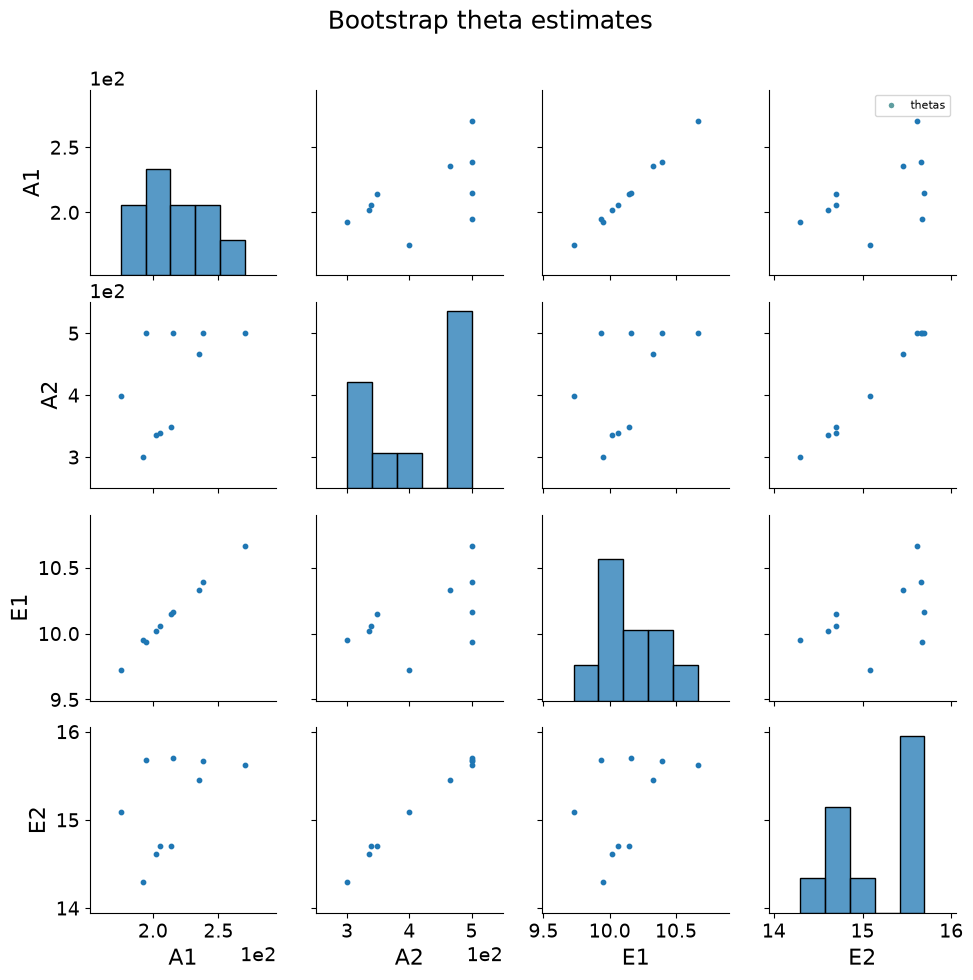

In [19]:
pyomo.contrib.parmest.graphics.pairwise_plot(
    bootstrap_theta, title="Bootstrap theta estimates"
)

Confidence regions can be plotted around the bootstrap estimates for various distributions with confidence $\alpha$.

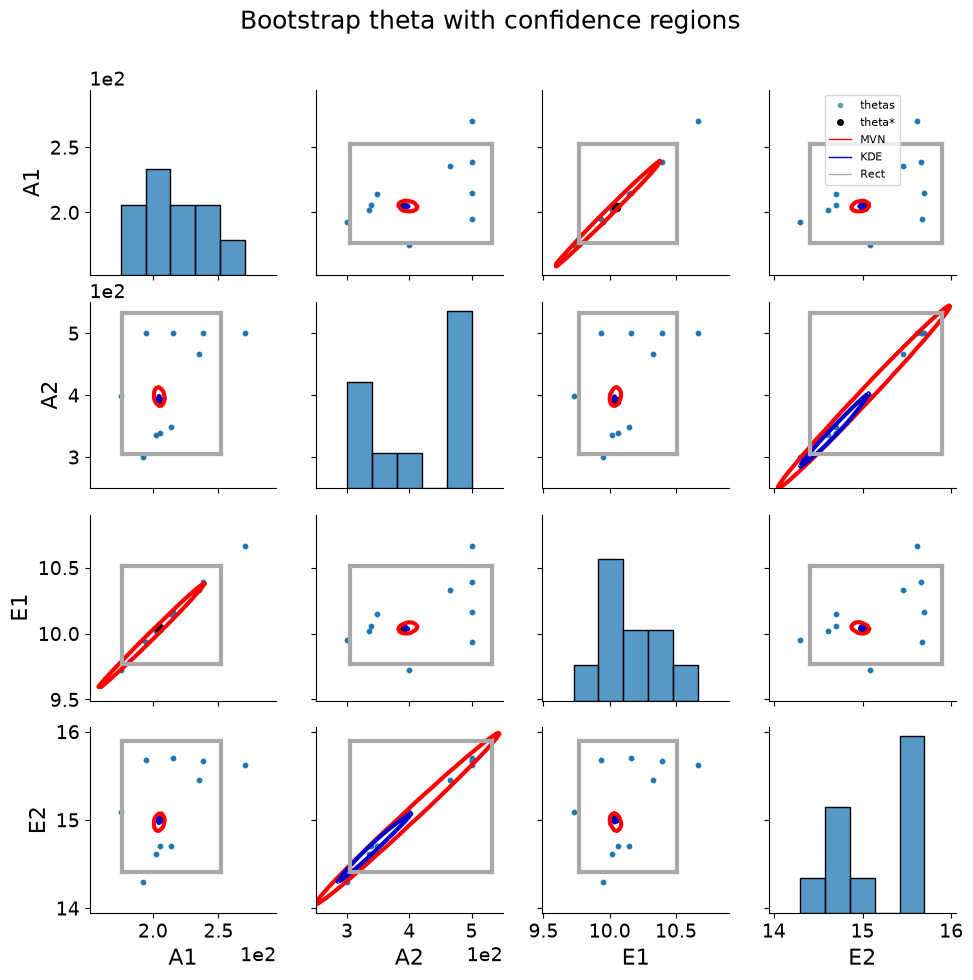

In [20]:
# plot bootstrap parameter estimates with confidence intervals
pyomo.contrib.parmest.graphics.pairwise_plot(
    bootstrap_theta,
    theta,
    0.8,
    ["MVN", "KDE", "Rect"],
    title="Bootstrap theta with confidence regions",
)

## Nonlinear confidence regions

The likelihood-ratio test (sometimes called the likelihood-ratio $\chi^2$ test) is a hypothesis test that helps one choose the “best” model between two models [link](https://www.statisticshowto.com/likelihood-ratio-tests/). Basically, the test compares the fit of two models. The null hypothesis is that the first model is the “best” model; It is rejected when the test statistic is large. In other words, if the null hypothesis is rejected, then the second model is a significant improvement over the first model.

In the last part of this notebook, we use the bootstrap parameter estimates to determine the goodness of fit using the likelihood-ratio $\chi^2$ test. More information can be found [here](https://pyomo.readthedocs.io/en/stable/contributed_packages/parmest/api.html#pyomo.contrib.parmest.parmest.Estimator.likelihood_ratio_test).

In [21]:
from itertools import product

### Likelihood ratio test

# generate arrays of parameter values
A1 = np.arange(180.0, 190.0, 1.0)
A2 = np.arange(395.0, 405.0, 1.0)
E1 = np.arange(5.0, 15.0, 1.0)
E2 = np.arange(10.0, 20.0, 1.0)

# format parameter values into a pandas dataframe to be provided as input to calculate
# corresponding objective function values
# theta_vals = pd.DataFrame(list(product(A1, A2, E1, E2)), columns=theta_names)
theta_vals = bootstrap_theta
obj_at_theta = pest.objective_at_theta(theta_vals)
print(obj_at_theta.head())

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

...

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

           A1          A2         E1         E2       obj
0  214.006137  348.422627  10.145437  14.702458  0.217455
1  202.042787  334.816774  10.020204  14.615005  0.217809
2  194.760940  499.988962   9.937919  15.673948  0.218506
3  215.170330  499.988460  10.162064  15.698181  0.218657
4  192.739676  300.015132   9.950830  14.294222  0.219718


In [22]:
LR = pest.likelihood_ratio_test(obj_at_theta, obj, [0.8, 0.85, 0.9, 0.95])
print(LR.head())

           A1          A2         E1         E2       obj   0.8  0.85   0.9  \
0  214.006137  348.422627  10.145437  14.702458  0.217455  True  True  True   
1  202.042787  334.816774  10.020204  14.615005  0.217809  True  True  True   
2  194.760940  499.988962   9.937919  15.673948  0.218506  True  True  True   
3  215.170330  499.988460  10.162064  15.698181  0.218657  True  True  True   
4  192.739676  300.015132   9.950830  14.294222  0.219718  True  True  True   

   0.95  
0  True  
1  True  
2  True  
3  True  
4  True  


The likelihood ratio test results with confidence $\alpha$ can be visualized as follows:

Objective contour plot for A1 A2 slice failed
Objective contour plot for A1 E1 slice failed
Objective contour plot for A2 E1 slice failed
Objective contour plot for A1 E2 slice failed
Objective contour plot for A2 E2 slice failed
Objective contour plot for E1 E2 slice failed
Objective contour plot for A2 A1 slice failed
Objective contour plot for E1 A1 slice failed
Objective contour plot for E2 A1 slice failed
Objective contour plot for E1 A2 slice failed
Objective contour plot for E2 A2 slice failed
Objective contour plot for E2 E1 slice failed


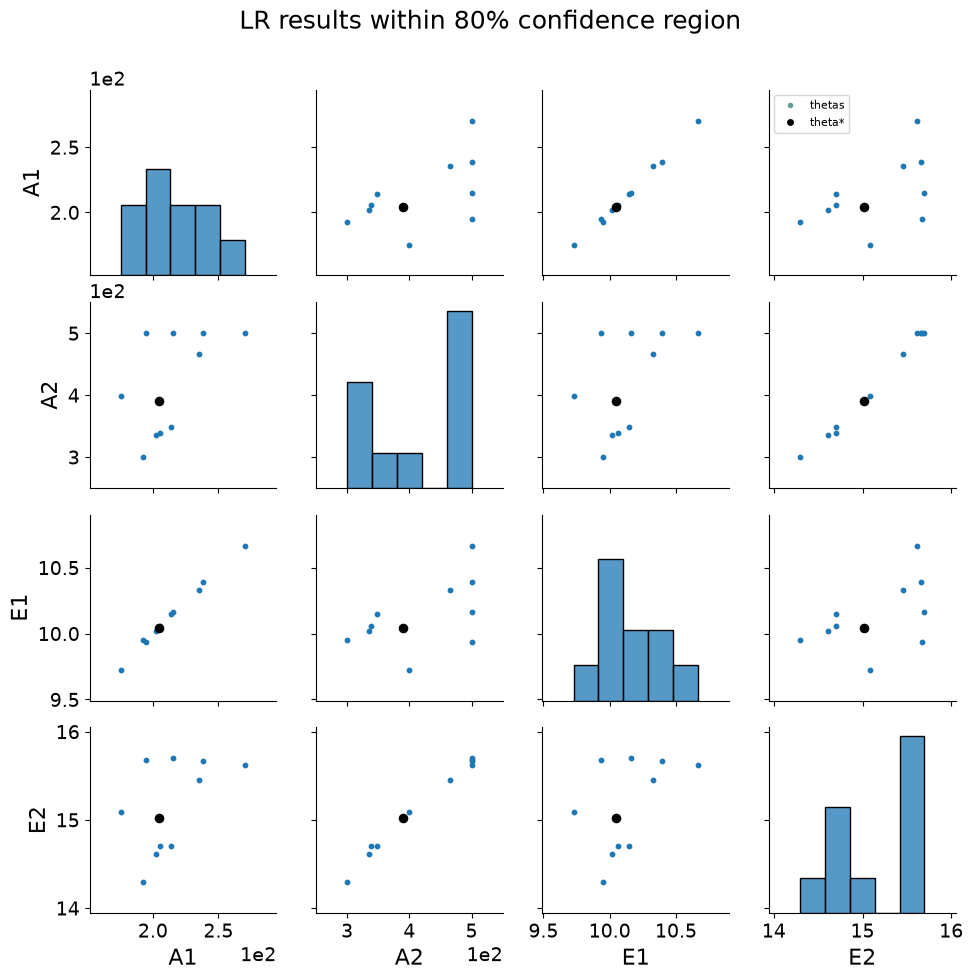

In [23]:
pyomo.contrib.parmest.graphics.pairwise_plot(
    LR, theta, 0.8, title="LR results within 80% confidence region"
)